In [8]:
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

print("Knižnice sú načítané.")


Knižnice sú načítané.


In [9]:
input_dir = Path(r"D:\hsu_semestralka\dataset_merged")
output_dir = Path(r"D:\hsu_semestralka\dataset_merged_gamma_correction_512_1.2_gamma")


valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


gamma = 1.2


save_as_rgb = True


target_size = (512, 512)


jpeg_quality = 95


overwrite_existing = True


preview_count = 6

print("Input:", input_dir)
print("Output:", output_dir)
print("Gamma:", gamma)
print("Target size:", target_size)


Input: D:\hsu_semestralka\dataset_merged
Output: D:\hsu_semestralka\dataset_merged_gamma_correction_512_1.2_gamma
Gamma: 1.2
Target size: (512, 512)


In [10]:
def check_paths(input_dir: Path, output_dir: Path):
    """
    Skontroluje, či sú vstupná a výstupná cesta bezpečne nastavené.
    """
    if not input_dir.exists():
        raise FileNotFoundError(f"Vstupný priečinok neexistuje: {input_dir}")

    input_resolved = input_dir.resolve()
    output_resolved = output_dir.resolve()

    if input_resolved == output_resolved:
        raise ValueError("input_dir a output_dir nesmú byť rovnaké.")

    try:
        output_resolved.relative_to(input_resolved)
        raise ValueError(
            "output_dir je vo vnútri input_dir. "
            "Daj výstupný priečinok mimo vstupného datasetu."
        )
    except ValueError as e:
        if "output_dir je vo vnútri input_dir" in str(e):
            raise

    output_dir.mkdir(parents=True, exist_ok=True)


def apply_gamma_correction(
    image: Image.Image,
    gamma=1.2,
    save_as_rgb=True
) -> Image.Image:
    """
    Aplikuje gamma correction na jeden obrázok.

    Funkcia nemení veľkosť obrázka.
    Funkcia nerobí crop ani padding.
    Funkcia neodstraňuje šum.
    """
    if gamma <= 0:
        raise ValueError("Gamma musí byť väčšia ako 0.")

    gray = image.convert("L")
    arr = np.array(gray).astype(np.float32) / 255.0

    corrected = np.power(arr, gamma)
    corrected = np.clip(corrected * 255.0, 0, 255).astype(np.uint8)

    result = Image.fromarray(corrected)

    if save_as_rgb:
        result = result.convert("RGB")

    return result


def resize_to_target(image: Image.Image, target_size=(512, 512)) -> Image.Image:
    """
    Natiahne obrázok na presný rozmer target_size.
    Nezachováva pomer strán a nepridáva blackbary.
    """
    return image.resize(target_size, Image.Resampling.LANCZOS)


def process_one_image(image_path: Path) -> Image.Image:
    """
    Načíta obrázok, aplikuje gamma correction a resize na 512×512.
    """
    img = Image.open(image_path).convert("RGB")

    gamma_img = apply_gamma_correction(
        img,
        gamma=gamma,
        save_as_rgb=save_as_rgb
    )

    resized = resize_to_target(gamma_img, target_size=target_size)

    return resized


def save_image(img: Image.Image, output_path: Path, jpeg_quality=95):
    """
    Uloží obrázok. Pri JPG/JPEG nastaví kvalitu.
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)

    suffix = output_path.suffix.lower()

    if suffix in {".jpg", ".jpeg"}:
        img.save(output_path, quality=jpeg_quality)
    else:
        img.save(output_path)


print("Funkcie sú pripravené.")


Funkcie sú pripravené.


In [11]:
check_paths(input_dir, output_dir)

image_paths = [
    path for path in input_dir.rglob("*")
    if path.is_file() and path.suffix.lower() in valid_extensions
]

images_by_folder = defaultdict(list)

for image_path in image_paths:
    images_by_folder[image_path.parent].append(image_path)

print(f"Počet nájdených obrázkov: {len(image_paths)}")
print(f"Počet priečinkov s obrázkami: {len(images_by_folder)}")
print("-" * 70)

for folder_path, folder_images in sorted(images_by_folder.items()):
    relative_folder = folder_path.relative_to(input_dir)
    print(f"{relative_folder}: {len(folder_images)} obrázkov")


Počet nájdených obrázkov: 14386
Počet priečinkov s obrázkami: 2
----------------------------------------------------------------------
NORMAL: 5848 obrázkov
PNEUMONIA: 8538 obrázkov


Ukážka: NORMAL\IM-0001-0001.jpeg
Originál: (1857, 1317) | Gamma + resize: (512, 512)


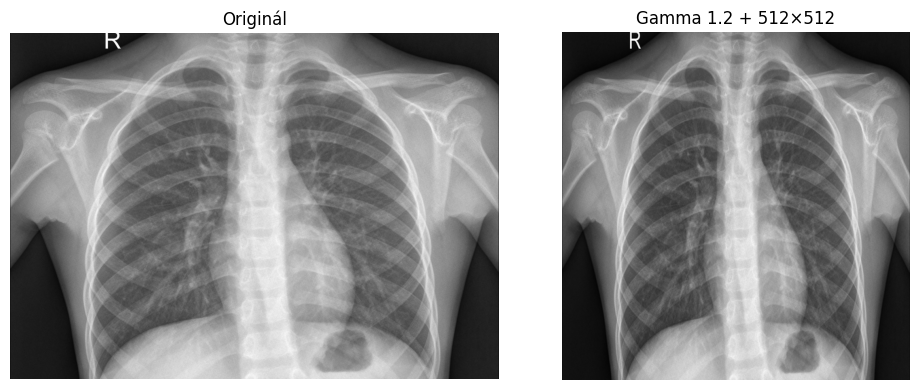

Ukážka: NORMAL\IM-0001-0001_aug_1366.jpg
Originál: (1857, 1317) | Gamma + resize: (512, 512)


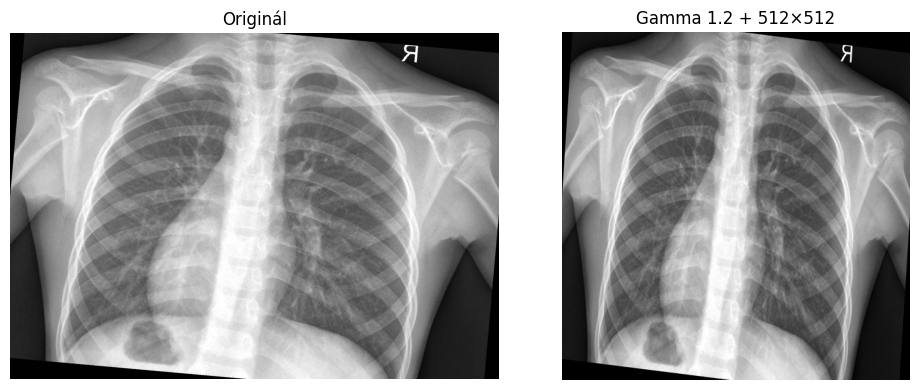

Ukážka: NORMAL\IM-0001-0001_aug_856.jpg
Originál: (1857, 1317) | Gamma + resize: (512, 512)


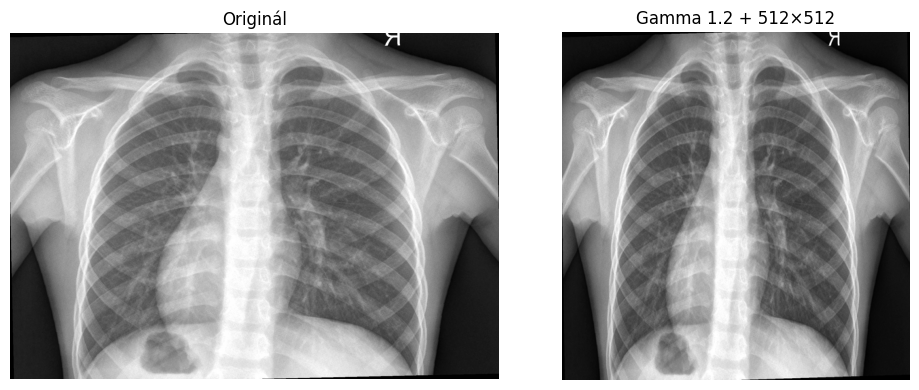

Ukážka: NORMAL\IM-0001-0001_aug_884.jpg
Originál: (1857, 1317) | Gamma + resize: (512, 512)


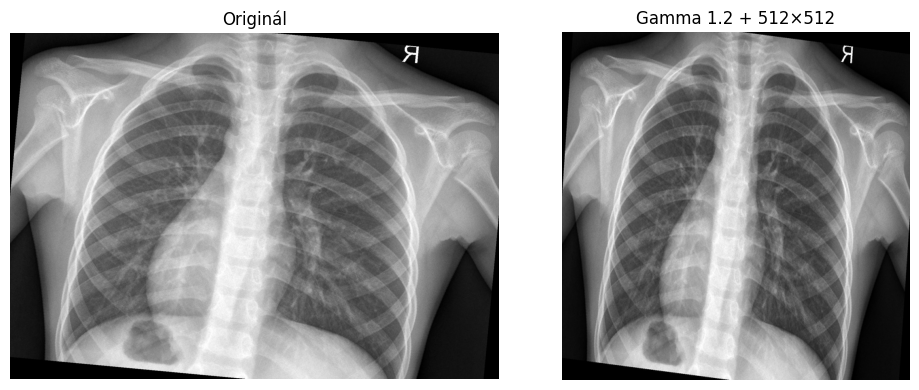

Ukážka: NORMAL\IM-0003-0001.jpeg
Originál: (2111, 1509) | Gamma + resize: (512, 512)


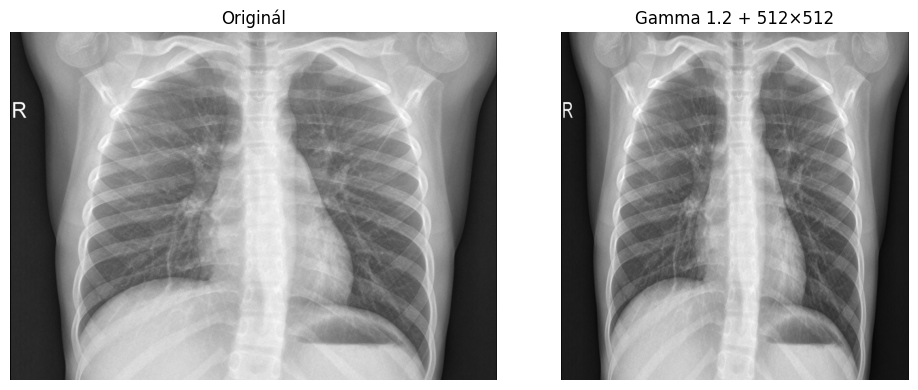

Ukážka: NORMAL\IM-0003-0001_aug_596.jpg
Originál: (2111, 1509) | Gamma + resize: (512, 512)


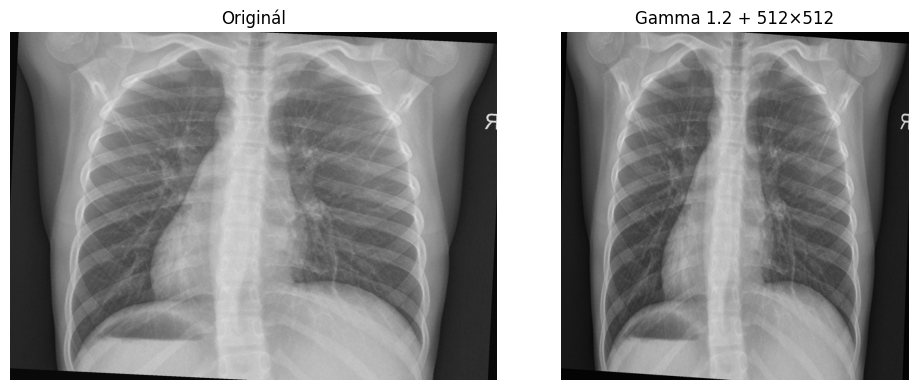

In [12]:
sample_paths = sorted(image_paths)[:preview_count]

if len(sample_paths) == 0:
    print("Nenašli sa žiadne obrázky.")
else:
    for image_path in sample_paths:
        original = Image.open(image_path).convert("RGB")
        processed = process_one_image(image_path)

        relative_path = image_path.relative_to(input_dir)

        print(f"Ukážka: {relative_path}")
        print(f"Originál: {original.size} | Gamma + resize: {processed.size}")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(original, cmap="gray")
        axes[0].set_title("Originál")
        axes[0].axis("off")

        axes[1].imshow(processed, cmap="gray")
        axes[1].set_title(f"Gamma {gamma} + 512×512")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


In [13]:
processed_count = 0
skipped_count = 0
error_count = 0

total_folders = len(images_by_folder)

for folder_index, (folder_path, folder_images) in enumerate(sorted(images_by_folder.items()), start=1):
    relative_folder = folder_path.relative_to(input_dir)

    print(f"\n[{folder_index}/{total_folders}] Spracováva sa priečinok:")
    print(f"    {relative_folder}")
    print(f"    Počet obrázkov v priečinku: {len(folder_images)}")

    for image_index, image_path in enumerate(sorted(folder_images), start=1):
        try:
            relative_path = image_path.relative_to(input_dir)
            output_path = output_dir / relative_path

            if output_path.exists() and not overwrite_existing:
                skipped_count += 1
            else:
                result_img = process_one_image(image_path)
                save_image(result_img, output_path, jpeg_quality=jpeg_quality)
                processed_count += 1

            if image_index % 50 == 0 or image_index == len(folder_images):
                print(f"    Spracované v tomto priečinku: {image_index}/{len(folder_images)}")

        except Exception as e:
            error_count += 1
            print(f"    CHYBA pri obrázku: {image_path}")
            print(f"    {e}")

print("\n" + "=" * 70)
print("Hotovo.")
print(f"Celkový počet spracovaných obrázkov: {processed_count}")
print(f"Preskočené existujúce obrázky: {skipped_count}")
print(f"Počet chýb: {error_count}")
print(f"Výstupný priečinok: {output_dir}")



[1/2] Spracováva sa priečinok:
    NORMAL
    Počet obrázkov v priečinku: 5848
    Spracované v tomto priečinku: 50/5848
    Spracované v tomto priečinku: 100/5848
    Spracované v tomto priečinku: 150/5848
    Spracované v tomto priečinku: 200/5848
    Spracované v tomto priečinku: 250/5848
    Spracované v tomto priečinku: 300/5848
    Spracované v tomto priečinku: 350/5848
    Spracované v tomto priečinku: 400/5848
    Spracované v tomto priečinku: 450/5848
    Spracované v tomto priečinku: 500/5848
    Spracované v tomto priečinku: 550/5848
    Spracované v tomto priečinku: 600/5848
    Spracované v tomto priečinku: 650/5848
    Spracované v tomto priečinku: 700/5848
    Spracované v tomto priečinku: 750/5848
    Spracované v tomto priečinku: 800/5848
    Spracované v tomto priečinku: 850/5848
    Spracované v tomto priečinku: 900/5848
    Spracované v tomto priečinku: 950/5848
    Spracované v tomto priečinku: 1000/5848
    Spracované v tomto priečinku: 1050/5848
    Spracované v

In [14]:
output_image_paths = [
    path for path in output_dir.rglob("*")
    if path.is_file() and path.suffix.lower() in valid_extensions
]

print(f"Počet vstupných obrázkov: {len(image_paths)}")
print(f"Počet výstupných obrázkov: {len(output_image_paths)}")

if len(image_paths) == len(output_image_paths):
    print("Počty sedia.")
else:
    print("Počty nesedia. Skontroluj logy a prípadné chyby.")


Počet vstupných obrázkov: 14386
Počet výstupných obrázkov: 14386
Počty sedia.
